Optimized parameters (phase-wrapped):
C_0 = 2.4339 ± 0.0055
theta0 = 0.6836 ± 0.0089  (raw 0.6836)
C_1  = 3.4012 ± 0.0022
theta1 = -0.9632 ± 0.0038  (raw -0.9632)
|theta0| + |theta1| = 1.6469 ± 0.0097 (π/2 = 1.5708)
R² = 1.0000
RMSE = 0.0013


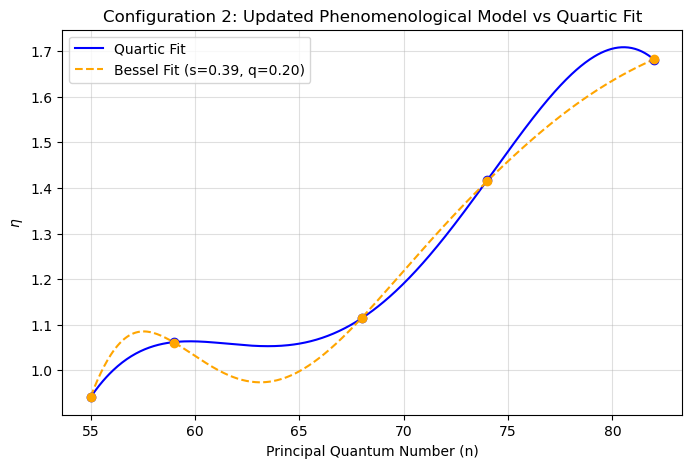

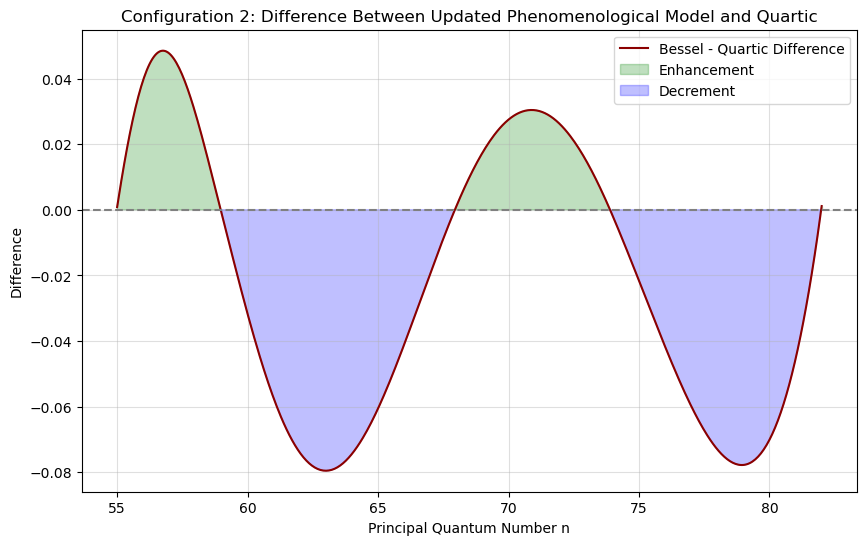

interactive(children=(FloatSlider(value=0.39, description='s', max=2.0, min=0.1, step=0.01), FloatSlider(value…

<function __main__.interactive_bessel_fit(s, q, Phi, config)>

In [1]:
"""
Dependencies
------------
This script requires the following Python packages:

- numpy
- matplotlib
- scipy
    - scipy.optimize (curve_fit)
    - scipy.special (Bessel functions)
    - scipy.interpolate (interp1d, PchipInterpolator, UnivariateSpline)
    - scipy.constants

- ipywidgets (only required if using interactive notebook version)
- IPython.display (only required if using interactive notebook version)

Tested with Python 3.x
"""



import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import jn
from scipy.interpolate import interp1d, PchipInterpolator, UnivariateSpline
import scipy.constants as const
import ipywidgets as widgets
from IPython.display import display, clear_output

# Constants
c = const.c
f = np.array([14.232, 12.694, 10.186, 9.673, 6.585, 5.0987, 4.893, 3.712, 3.350]) * 1e9 # Autler-Townes transition frequency
n = np.array([53, 55, 59, 60, 68, 74, 75, 82, 85]) # tested principal quantum numbers
idx_map_1 = [0, 1, 4, 6, 8]  # Configuration 1 tested principal quantum numbers
idx_map_2 = [1, 2, 4, 5, 7]  # Configuration 2 tested principal quantum numbers
l = c / f  # wavelength
cell_width = 0.0175 # [m]
cell_length = 0.075 # [m]


# r-squared calculator
def r2_score_np(y_true, y_pred):
    # Coefficient of determination
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1.0 - ss_res / ss_tot if ss_tot != 0 else 0.0

# root mean square error calculator
def rmse_np(y_true, y_pred):
    # Root mean squared error
    return np.sqrt(np.mean((y_true - y_pred)**2))


# Quartic fits for each configuration
def eta_config1(n):
    return -1.1333e-05 * n**4 + 3.1393e-03 * n**3 - 3.2492e-01 * n**2 + 1.4887e+01 * n - 2.5376e+02

def eta_config2(n):
    return -1.6225e-05 * n**4 + 4.4086e-03 * n**3 - 4.4523e-01 * n**2 + 1.9832e+01 * n - 3.2801e+02

def wrap_phase(phi):
    """Wrap phase to [-pi, pi]. Works with scalars or numpy arrays."""
    return (phi + np.pi) % (2*np.pi) - np.pi

# Interactive function
def interactive_bessel_fit(s, q, Phi, config):
    clear_output(wait=True)

    # Select configuration
    if config == 'Configuration 1':
        idx_map = idx_map_1
        n_sel = n[idx_map]
        eta_sel = eta_config1(n_sel)
        eta_func = eta_config1
    else:
        idx_map = idx_map_2
        n_sel = n[idx_map]
        eta_sel = eta_config2(n_sel)
        eta_func = eta_config2

    # Compute the arguments of Bessel functions
    R1 = cell_width/ 2                 # vapor cell radius
    R2 = cell_length               # vapor cell length
    # radial and longitudinal offsets, s and q, respectively, select which antinode is sampled
    K1R = (2 * np.pi/(s * l[idx_map])) * R1            # radial argument of J_n (k1*r_radius) [expressed in the traditional form]
    K2R = (2 * np.pi * q / l[idx_map]) * R2            # axial argument of J_n (k2*r_length) [expressed in the traditional form]

    
    # Updated for PCHIP:
    # PCHIP is a shape-preserving interpolation method. It ensures that the interpolated curve does not overshoot the data points.
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.pchip_interpolate.html
    K1R_interp = PchipInterpolator(n_sel, K1R) # this interpolates k(radial) across the range of tested frequencies for a set of principal quantum numbers
    K2R_interp = PchipInterpolator(n_sel, K2R) # this interpolates k(axial) across the range of tested frequencies for a set of principal quantum numbers


    # Model equation: E(rho, q, Phi) = C_0 * J0(k * rho) * cos (k * q + theta0) + C_1 * J1(k * rho) * cos (k * q + theta1) * cos(Phi)
    def bessel_model_mix(n_in, C_0, theta0, C_1, theta1):
        k1r = K1R_interp(n_in)
        k2r = K2R_interp(n_in)

        theta0 = wrap_phase(theta0) # phase shift for m = 0 term
        theta1 = wrap_phase(theta1) # phase shift for m = 1 term

        J0 = jn(0, k1r) # Zero-order Bessel function applied along the radial direction
        J1 = jn(1, k1r) # First-order Bessel function applied along the radial direction

        E_m0 = C_0 * J0 * np.cos(k2r + theta0) # E(r,theta)  m = 0
        E_m1 = C_1 * J1 * np.cos(k2r + theta1) * np.cos(np.deg2rad(Phi)) # E(r, theta, phi) m = 1
        return E_m0 + E_m1
    

    p0     = [1.0, 0.0, 1.0, 0.0]  # Initial guess for: C_0, theta0, C_1, theta1
    bounds = ([0.0, -np.pi, 0.0, -np.pi],
              [ np.inf,  np.pi,  np.inf,  np.pi]) # Restrict coefficients to be positive; full range for phase shifts
    popt, pcov = curve_fit(bessel_model_mix, n_sel, eta_sel, p0=p0, bounds=bounds)

    J_fit = bessel_model_mix(n_sel, *popt)
    r2 = r2_score_np(eta_sel, J_fit)
    rmse = rmse_np(eta_sel, J_fit) # compares the quatic fit to the new phenomenological model

    # Smooth curves
    n_smooth = np.linspace(min(n_sel), max(n_sel), 500)
    eta_smooth = eta_func(n_smooth)
    J_smooth = bessel_model_mix(n_smooth, *popt)

    C_0_raw, theta0_raw, C_1_raw, theta1_raw   = popt
    C_0 = C_0_raw
    theta0 = wrap_phase(theta0_raw)
    C_1 = C_1_raw
    theta1 = wrap_phase(theta1_raw)
    phase_sum = np.abs(theta0) + np.abs(theta1)
    
    

    # Standard errors (1σ) from covariance
    uncertainties = np.sqrt(np.diag(pcov))
    u_theta0, u_theta1, u_C_0, u_C_1 = uncertainties

    # Phase sum uncertainty (independent errors)
    u_phase_sum = np.sqrt(u_theta0**2 + u_theta1**2)

    print("Optimized parameters (phase-wrapped):")
    print(f"C_0 = {C_0:.4f} ± {u_C_0:.4f}")
    print(f"theta0 = {theta0:.4f} ± {u_theta0:.4f}  (raw {theta0_raw:.4f})")
    print(f"C_1  = {C_1:.4f} ± {u_C_1:.4f}")
    print(f"theta1 = {theta1:.4f} ± {u_theta1:.4f}  (raw {theta1_raw:.4f})")
    print(f"|theta0| + |theta1| = {phase_sum:.4f} ± {u_phase_sum:.4f} "
      f"(π/2 = {np.pi/2:.4f})")
    print(f"R² = {r2:.4f}")
    print(f"RMSE = {rmse:.4f}")

    # Plot fits
    plt.figure(figsize=(8, 5))
    plt.plot(n_smooth, eta_smooth, label='Quartic Fit', color='blue')
    plt.plot(n_smooth, J_smooth, label=f'Bessel Fit (s={s:.2f}, q={q:.2f})', color='orange', linestyle='--')
    plt.scatter(n_sel, eta_sel, color='blue', zorder=3)
    plt.scatter(n_sel, J_fit, color='orange', zorder=3)
    plt.xlabel('Principal Quantum Number (n)')
    plt.ylabel(r'$\eta$')
    plt.title(f'{config}: Updated Phenomenological Model vs Quartic Fit')
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()

    # Difference plot
    difference = J_smooth - eta_smooth
    plt.figure(figsize=(10, 6))
    plt.plot(n_smooth, difference, color='darkred', label='Bessel - Quartic Difference')
    plt.axhline(0, color='gray', linestyle='--')
    plt.fill_between(n_smooth, difference, 0, where=(difference > 0), color='green', alpha=0.25, label='Enhancement')
    plt.fill_between(n_smooth, difference, 0, where=(difference < 0), color='blue',  alpha=0.25, label='Decrement')
    plt.xlabel('Principal Quantum Number n')
    plt.ylabel('Difference')
    plt.title(f'{config}: Difference Between Updated Phenomenological Model and Quartic')
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()

# Widgets
dropdown_config = widgets.Dropdown(options=['Configuration 1', 'Configuration 2'], value='Configuration 2', description='Config')
slider_s = widgets.FloatSlider(value=0.39, min=0.1, max=2.0, step=0.01, description='s')
slider_q = widgets.FloatSlider(value=0.20, min=0.01, max=1.0, step=0.01, description='q')
slider_Phi = widgets.FloatSlider(value=0, min=0, max=360, step=1.0, description='Phi')

def update_sliders(change):
    if change['new'] == 'Configuration 1':
        slider_s.value = 0.84
        slider_q.value = 0.27
        slider_Phi.value = 0.00
    elif change['new'] == 'Configuration 2':
        slider_s.value = 0.39
        slider_q.value = 0.20
        slider_Phi.value = 0.00

dropdown_config.observe(update_sliders, names='value')

widgets.interact(interactive_bessel_fit, config=dropdown_config, s=slider_s, q=slider_q, Phi=slider_Phi)

# The Modeling

## The Helmoltz equation and its general solution
$$
\nabla^2 \psi + k^2\psi = 0
$$


$$
\psi_{(r,\phi,z)} = \sum_{-\infty}^{\infty}\left[ A_m J_m(k_r r) + B_m Y_m(k_r r) \right]e^{\pm ik_z z}e^{\pm im\phi}
$$

## The Truncated Helmholtz model
$$
\eta(n) = C_0 J_0(k r) \cos(k z + w_1)  + C_1 J_1(k r) \cos(k z + w_2) \sin(\phi)
$$
where $C_0, C_1, w_1~$, and $w_2$ are least-squares fit parameters and $k=2\pi/\lambda$ where $\lambda$ corresponds to the Autler--Townes splitting driving frequency in free-space.  This is a two-term truncated form (real parts only) of the general solution to the Helmholtz equation in cylindrical coordinates.  This equation states that the electric field behaves as a weakly guided  standing wave.
The "weakly guided" components are $\cos(k z + w_1)$ and $\cos(k z + w_2)$.  The "standing wave" components are $C_0 J_0(k r)$ and $C_1 J_1(k r)$.  The fitting model can trade amplitude and phase without penalty.  This means that while the phase shift phenomenologically encode the boundary conditions at the endcaps of the vapor cell, an additional phase shift of $\pm\pi$ is equally valid and thus the concave up portion of the plot where the truncated model dips $\bf{below}$ the quartic is just as valid as a concave down segment that sweeps $\bf{above}$ the quartic in that curved region.  Because the vapor cell does not impose perfect electromagnetic boundary conditions, the absolute phase of the standing wave cannot be uniquely fixed, motivating a truncated, phase-flexible modeling approach.